In [1]:
from qrwqkd import EntangledWalkersQKD, plot_heatmap
import numpy as np

c:\Users\keygo\Anaconda3\envs\qrwqkd\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


### Secure Quantum Key Distribution via Entangled Quantum Walkers

Initialize the protocol with quantum random walk (QRW) parameters

In [3]:
coin_params = {"a": 0.85, "phi": np.pi / 4, "theta": 0.635, "lam": 0}
protocol = EntangledWalkersQKD(steps=2, coin_params=coin_params)
print(protocol)

2-step entangled walkers QKD protocol
coin parameters:
-----------
Initial coin state: 0.85|00> + (0.37249161064378356+0.37249161064378356j)|11>
Coin-flip operator U(θ,λ) = U(0.635, 0) = 
 [[ 0.95001887+0.j -0.31219249-0.j]
 [ 0.31219249+0.j  0.95001887+0.j]]


Visualize the protocol as a quantum circuit

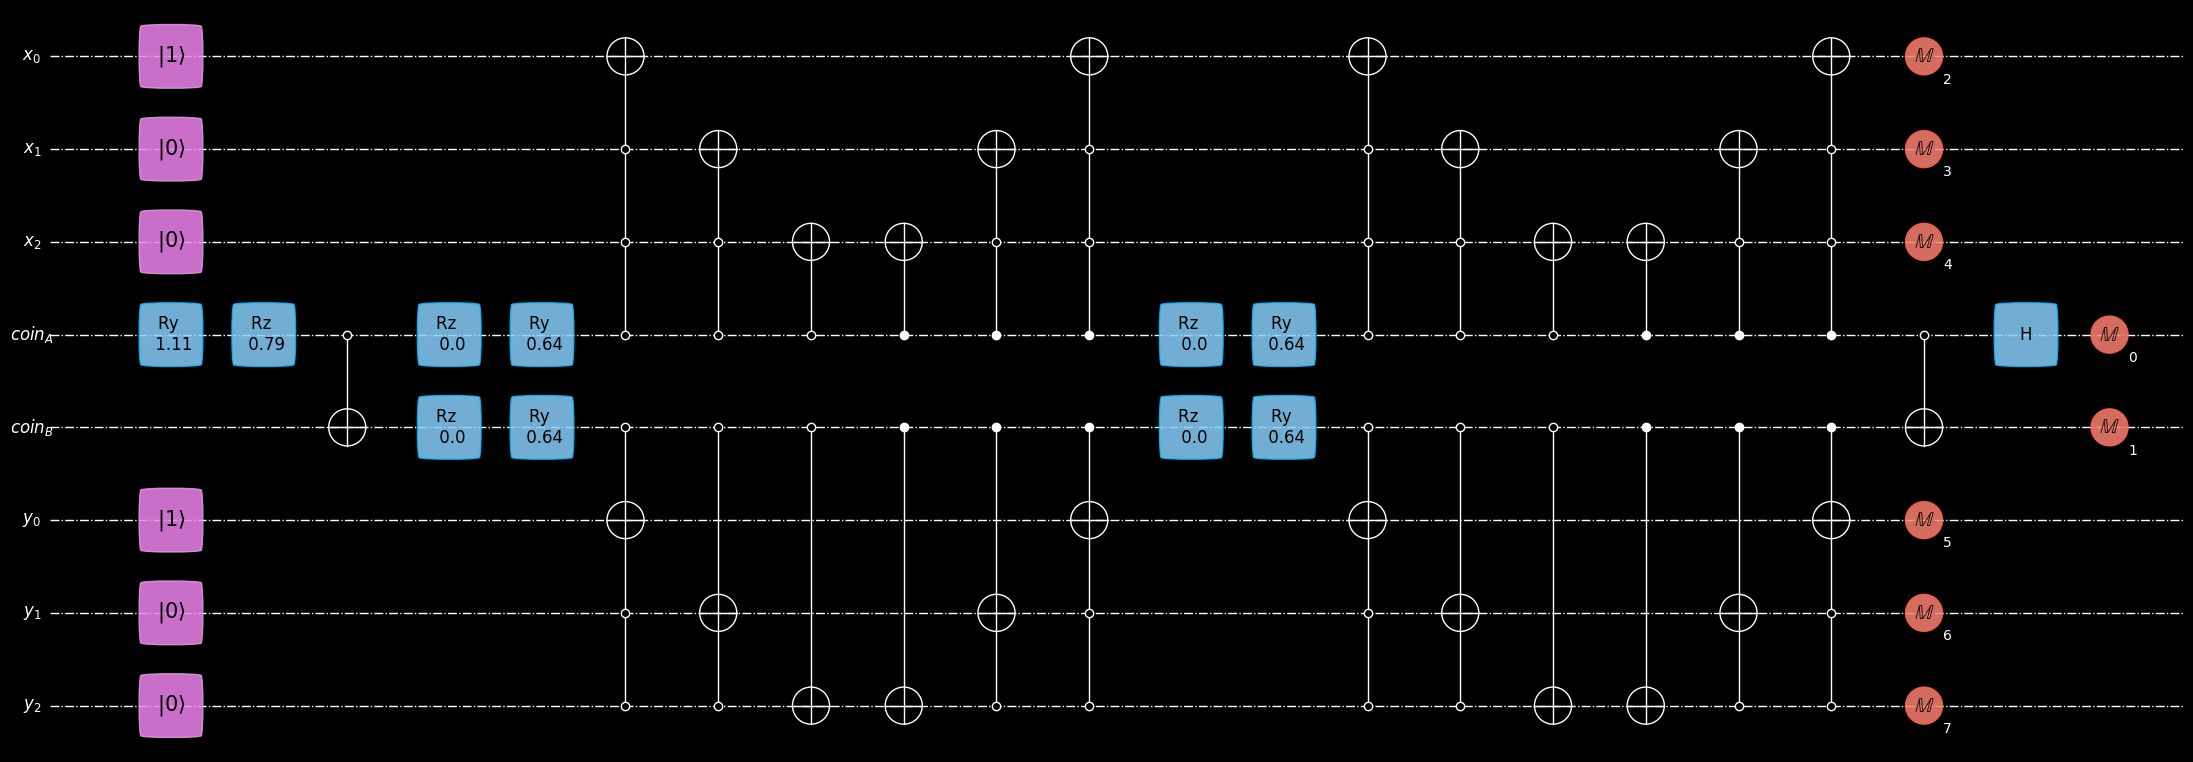

In [3]:
from geqo.simulators import ensembleSimulatorCuPy
from geqo.visualization import plot_mpl

circuit, params = protocol.quantum_circuit()  # load the quantum circuit of the protocol
sim = ensembleSimulatorCuPy(8, 8)
sim.values = params
plot_mpl(circuit, backend=sim, style="geqo_dark")

BSM outcomes and joint probability distribution of walker positions

In [4]:
# simulate the circuit and calculate the probability distributions
stats = protocol.evaluate_circuit(circuit, params, normalize=True)

for outcome, ensemble in stats.items():
    print(f"BSM outcome {outcome}: \n-------------\nprobability = {ensemble[0]}")
    print("joint position distribution (Alice, Bob):")
    for key, item in ensemble[1].items():
        print(f"{key}, prob = {item}")
    print("-" * 30 + "\n" + "-" * 30)

BSM outcome 00: 
-------------
probability = 0.3944386616615785
joint position distribution (Alice, Bob):
(-2, -2), prob = 0.667934419903556
(-2, 0), prob = 0.0035974624964609106
(0, -2), prob = 0.0035974624964609098
(0, 0), prob = 0.01966659694006826
(0, 2), prob = 0.0035974624964609098
(2, 0), prob = 0.0035974624964609106
(2, 2), prob = 0.298009133170532
------------------------------
------------------------------
BSM outcome 01: 
-------------
probability = 0.10918191157112318
joint position distribution (Alice, Bob):
(-2, 0), prob = 0.2605811842538186
(-2, 2), prob = 0.12034958896971477
(0, -2), prob = 0.26058118425381865
(0, 0), prob = 0.005613910645729801
(0, 2), prob = 0.11626227145360166
(2, -2), prob = 0.12034958896971477
(2, 0), prob = 0.11626227145360166
------------------------------
------------------------------
BSM outcome 10: 
-------------
probability = 0.3878104526918651
joint position distribution (Alice, Bob):
(-2, -2), prob = 0.679350329099543
(-2, 0), prob = 0.00

Simulate the protocol using the recursive simulator

BSM outcome 00: 
probability = 0.3944386616615785 
---------------------------


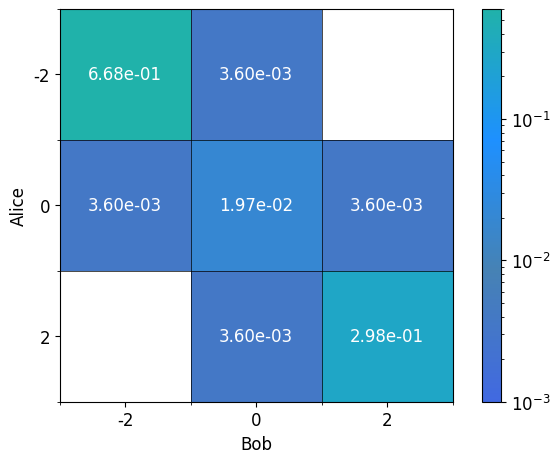

BSM outcome 01: 
probability = 0.1091819115711232 
---------------------------


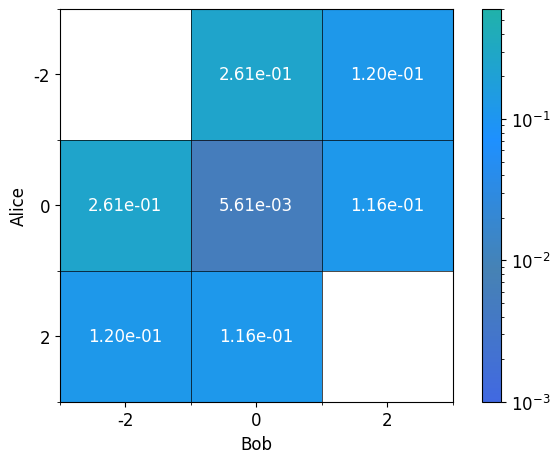

BSM outcome 10: 
probability = 0.3878104526918652 
---------------------------


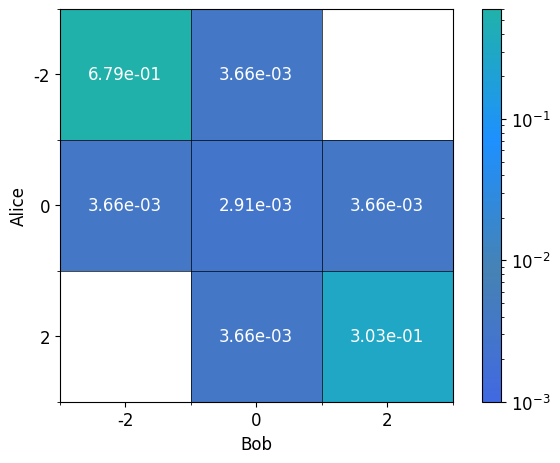

BSM outcome 11: 
probability = 0.10856897407543294 
---------------------------


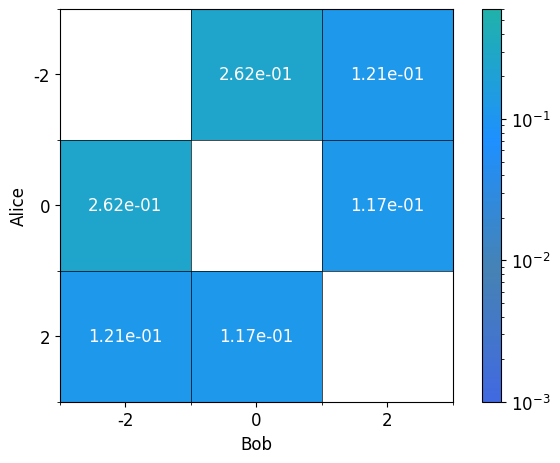

In [4]:
bsm_outcomes, all_probs = protocol.recursive_simulate(normalize=True)
for key, value in bsm_outcomes.items():
    print(
        f"BSM outcome {key}: \nprobability = {value[0]} \n---------------------------"
    )
    plot_heatmap(value[1])

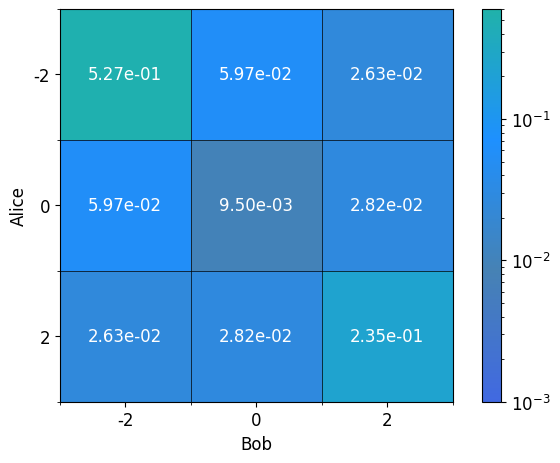

In [5]:
# plot the joint probability distribution aggregated over all BSM outcomes
plot_heatmap(all_probs)

Multiple rounds of key exchange without an eavesdropper 

In [6]:
sifted_keys = protocol.distribute_key(nrounds=10000)  # exchange 10000 raw keys

Shared key rate: 0.8093
First 100 sifted keys:[-2, -2, 2, -2, 2, -2, -2, -2, -2, -2, 2, 2, 2, -2, -2, -2, 2, -2, -2, -2, 2, -2, 2, 2, -2, -2, 2, 2, -2, -2, -2, 2, -2, -2, -2, -2, 2, 2, -2, -2, 2, -2, 2, 2, -2, -2, -2, -2, 2, -2, 2, -2, -2, -2, -2, -2, 2, 2, 2, -2, -2, 2, -2, -2, 2, -2, -2, -2, -2, -2, -2, 2, -2, 2, -2, -2, 2, 2, -2, -2, -2, -2, -2, 2, -2, 2, -2, -2, -2, -2, -2, 2, 2, -2, 2, -2, 2, -2, 2, -2]
Shannon entropy of sifted keys: 0.9098370681644933
--------------------------------------------------
Security Check 
--------------------------------------------------
Total variation distance (TVD) for position measurements: 0.0089432009353077
Total variation distance (TVD) for BSM: 0.0038794267672982233


The sifted keys are a bit biased as expected for our choice of coin parameters. We can also generate almost unbiased keys by choosing a balanced initial coin state ($a = 1/\sqrt{2}$)

In [2]:
coin_params2 = {"a": 1 / 2**0.5, "phi": np.pi / 4, "theta": 0.635, "lam": 0}
unbiased_protocol = EntangledWalkersQKD(steps=2, coin_params=coin_params2)
unbiased_sifted_keys = unbiased_protocol.distribute_key(nrounds=10000)

Shared key rate: 0.8145
First 100 sifted keys:[-2, -2, -2, -2, 2, 2, 2, 2, -2, 2, -2, -2, 2, 2, 2, -2, -2, -2, -2, 2, 2, 2, 2, -2, -2, -2, 2, 2, -2, 2, 2, 2, -2, -2, 2, -2, -2, -2, -2, 2, 2, 2, -2, 2, 2, -2, -2, -2, 2, 2, -2, 2, -2, 2, 2, 2, -2, -2, 2, -2, 2, 2, 2, 2, 2, -2, -2, 2, -2, -2, 2, -2, 2, -2, 2, 2, -2, -2, 2, -2, 2, -2, -2, -2, -2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, -2, 2, -2]
Shannon entropy of sifted keys: 0.9999388366829689
--------------------------------------------------
Security Check 
--------------------------------------------------
Total variation distance (TVD) for position measurements: 0.009850369560533239
Total variation distance (TVD) for BSM: 0.0061520201133864125
